# Homework 3
Consider a square wave force signal $f (t)$ with period 0.1 seconds. f = 1 at [0,0.025] and [0.075,0.1], f= -1 at [0.025,0.075].
Calculate the coefficients of the Fourier series expressed in exponential form, up to the 7th harmonic,
of this function.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sympy 
from sympy import simplify, Symbol, integrate

T = 0.1 # Period of the signal
f = 1 / T # Frequency of the signal
w_n = 2 * np.pi * f # Angular frequency
t = Symbol('t', real=True)
n = Symbol('n', integer=True)


Complex Fourier Coefficients:

C_-7 = -0.09095 -0.00000j  |C|=0.09095
C_-6 = -0.00000 +0.00000j  |C|=0.00000
C_-5 = 0.12732 +0.00000j  |C|=0.12732
C_-4 = -0.00000 +0.00000j  |C|=0.00000
C_-3 = -0.21221 +0.00000j  |C|=0.21221
C_-2 = -0.00000 +0.00000j  |C|=0.00000
C_-1 = 0.63662 +0.00000j  |C|=0.63662
C_ 0 = -0.00000 +0.00000j  |C|=0.00000
C_ 1 = 0.63662 -0.00000j  |C|=0.63662
C_ 2 = -0.00000 -0.00000j  |C|=0.00000
C_ 3 = -0.21221 -0.00000j  |C|=0.21221
C_ 4 = -0.00000 -0.00000j  |C|=0.00000
C_ 5 = 0.12732 -0.00000j  |C|=0.12732
C_ 6 = -0.00000 -0.00000j  |C|=0.00000
C_ 7 = -0.09095 +0.00000j  |C|=0.09095


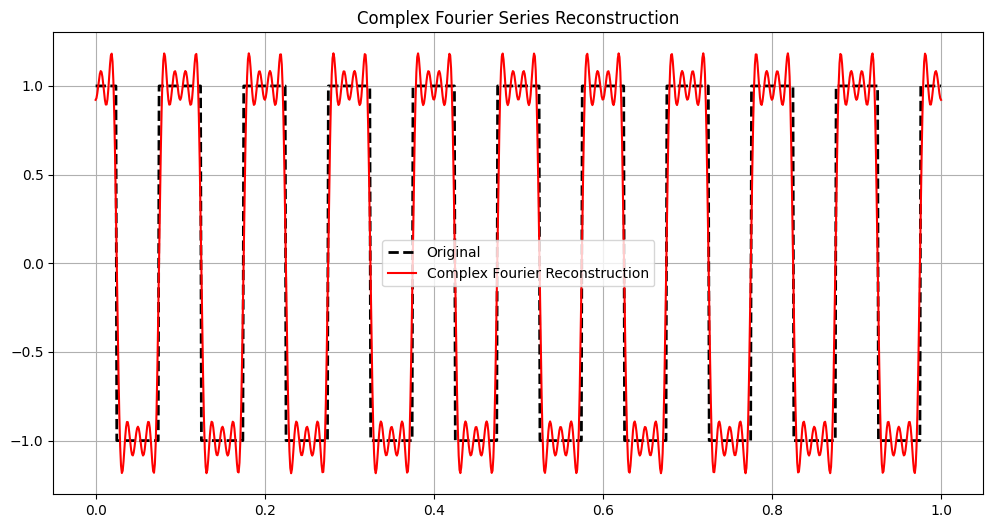

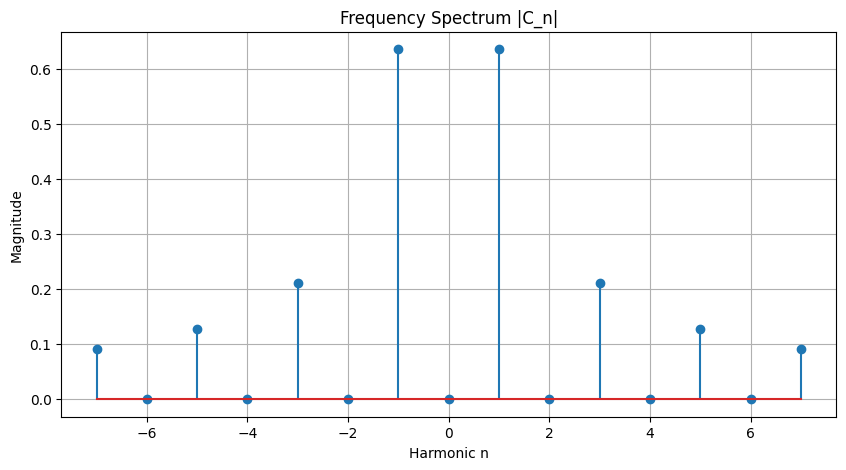

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# =====================================
# 基本参数
# =====================================

T = 0.1
omega0 = 2*np.pi/T

# =====================================
# 定义周期函数（考试只改这里）
# =====================================

def f(t):
    t_mod = np.mod(t, T)

    if (0 <= t_mod < 0.025) or (0.075 <= t_mod < 0.1):
        return 1
    else:
        return -1


# =====================================
# Complex Fourier coefficient
# =====================================

def Cn(n):
    real_part = quad(lambda t: f(t)*np.cos(n*omega0*t), 0, T)[0]
    imag_part = quad(lambda t: -f(t)*np.sin(n*omega0*t), 0, T)[0]

    return (real_part + 1j*imag_part) / T


# =====================================
# 打印系数
# =====================================

N = 7

print("\nComplex Fourier Coefficients:\n")

coeffs = {}

for n in range(-N, N+1):
    c = Cn(n)
    coeffs[n] = c
    
    print(f"C_{n:>2} = {c.real:.5f} {c.imag:+.5f}j  |C|={abs(c):.5f}")


# =====================================
# 重构函数
# =====================================

def fourier_complex(t, coeffs):
    result = np.zeros_like(t, dtype=complex)

    for n, c in coeffs.items():
        result += c * np.exp(1j*n*omega0*t)

    return result.real   # 理论上虚部≈0


# =====================================
# Plot
# =====================================

t = np.linspace(0, 1, 1000)

f_original = np.array([f(ti) for ti in t])
f_reconstructed = fourier_complex(t, coeffs)

plt.figure(figsize=(12,6))

plt.plot(t, f_original, 'k--', linewidth=2, label='Original')
plt.plot(t, f_reconstructed, 'r', label='Complex Fourier Reconstruction')

plt.title("Complex Fourier Series Reconstruction")
plt.grid()
plt.legend()
plt.show()


# =====================================
# Frequency Spectrum
# =====================================

plt.figure(figsize=(10,5))

n_vals = list(coeffs.keys())
magnitudes = [abs(c) for c in coeffs.values()]

plt.stem(n_vals, magnitudes)

plt.title("Frequency Spectrum |C_n|")
plt.xlabel("Harmonic n")
plt.ylabel("Magnitude")
plt.grid()

plt.show()


如果只考虑positive frequency

Harmonic (n)    | Real Part Re(Fn)     | Amplitude An (2*Re) 
------------------------------------------------------------
1               | 0.636620             | 1.273240            
2               | -0.000000            | -0.000000           
3               | -0.212207            | -0.424413           
4               | -0.000000            | -0.000000           
5               | 0.127324             | 0.254648            
6               | -0.000000            | -0.000000           
7               | -0.090946            | -0.181891           


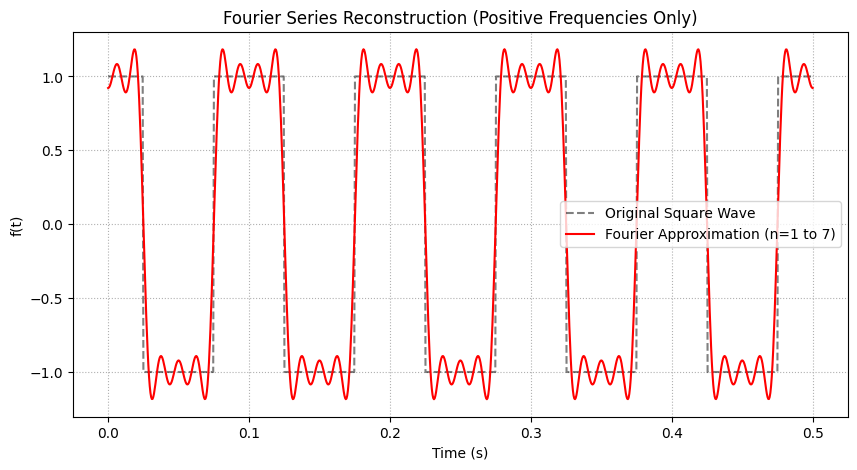

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# 1. 基本参数设置 [cite: 309]
T = 0.1             # 周期
w1 = 2 * np.pi / T  # 基频 (rad/s)
t_start = 0
t_end = 0.5         # 绘制 5 个周期
num_points = 1000

# 2. 定义原始方波函数 (根据教授定义的 [0, T/4]为1, [T/4, 3T/4]为-1, [3T/4, T]为1) [cite: 312, 313, 318]
def f_original(t):
    t_mod = np.mod(t, T)
    if (t_mod < T/4) or (t_mod >= 3*T/4):
        return 1.0
    else:
        return -1.0

# 3. 计算并打印傅里叶系数 (1 到 7 项)
print(f"{'Harmonic (n)':<15} | {'Real Part Re(Fn)':<20} | {'Amplitude An (2*Re)':<20}")
print("-" * 60)

# 存储用于绘图的系数
harmonics = [1, 2, 3, 4, 5, 6, 7]
A_coeffs = {}

for n in harmonics:
    # 使用数值积分计算复数系数 Fn 的实部 [cite: 311]
    # Re(Fn) = (1/T) * \int f(t) * cos(n*w1*t) dt
    integrand = lambda t: f_original(t) * np.cos(n * w1 * t)
    re_fn, _ = quad(integrand, 0, T)
    re_fn = re_fn / T
    
    # 计算正频率振幅 An = 2 * Re(Fn)
    an = 2 * re_fn
    A_coeffs[n] = an
    
    # 打印结果 [cite: 319, 323, 335, 339, 351, 354, 368, 371]
    print(f"{n:<15} | {re_fn:<20.6f} | {an:<20.6f}")

# 4. 信号重建 (仅使用正频率项/三角形式)
t_vec = np.linspace(t_start, t_end, num_points)
f_approx = np.zeros_like(t_vec)

# 只叠加正频率的余弦波 
# 公式: f(t) \approx \sum An * cos(n * w1 * t)
for n in harmonics:
    f_approx += A_coeffs[n] * np.cos(n * w1 * t_vec)

# 5. 绘图
plt.figure(figsize=(10, 5))
f_orig_vec = np.array([f_original(ti) for ti in t_vec])

plt.plot(t_vec, f_orig_vec, 'k--', label='Original Square Wave', alpha=0.5)
plt.plot(t_vec, f_approx, 'r-', label='Fourier Approximation (n=1 to 7)')

plt.title('Fourier Series Reconstruction (Positive Frequencies Only)')
plt.xlabel('Time (s)')
plt.ylabel('f(t)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()